# AML Dataset Analysis

This notebook analyses three synthetic Anti-Money Laundering (AML) datasets:

| # | Dataset | Source |
|---|---|---|
| 1 | **IBM AMLSim** (HI-Small) | [Kaggle](https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml) |
| 2 | **AMLNet** *(AMLGentex-equivalent)* | [Zenodo](https://zenodo.org/records/21237971) |
| 3 | **SAML-D** | [Kaggle](https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml) |


## File placement

| Dataset | Required file |
|---|---|
| IBM AMLSim | `Code/data/ibm_amlsim/HI-Small_Trans.csv` |
| AMLNet | `Code/data/amlgentex/transactions.csv` |
| SAML-D | `Code/data/saml_d/SAML-D.csv` |

## Setup

In [ ]:
import sys
import os

# Make sure the Code directory is on the path so Python can find our modules.
CODE_DIR = os.path.dirname(os.path.abspath("__file__"))
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from loader.dataset_factory import DatasetFactory

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "font.family": "sans-serif",
})

print("Available datasets:", DatasetFactory.available_datasets())

Available datasets: ['ibm_amlsim', 'amlgentex', 'saml_d']


---
## 1  IBM AMLSim (HI-Small)

> **Source**: [Kaggle – IBM Transactions for AML](https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml)  
> **Generator**: IBM AMLSim multi-agent simulator ([GitHub](https://github.com/IBM/AMLSim))  
> **Files**: `HI-Small_Trans.csv` (required) + `HI-Small_accounts.csv` (optional node metadata)


### About Dataset Variants
The IBM AMLSim dataset comes in three independent sizes (Small, Medium, Large) and two variants per size: **HI** (High Illicit) and **LI** (Low Illicit). The High Illicit datasets inject a slightly higher ratio of money-laundering examples (~0.1%) to make predictive modeling easier, while Low Illicit has a more realistic ratio.

| Dataset | Transactions | Accounts (Nodes) | Time Span Simulated |
| :--- | :--- | :--- | :--- |
| **HI-Small** | ~5 Million | ~500,000 | ~10 days |
| **HI-Medium** | ~31 Million | ~2,000,000 | ~16 days |
| **HI-Large** | ~175 Million | >2,000,000 | ~97 days |

Because **HI-Small** already contains over 5 million edges, it provides more than enough complexity for exploratory data analysis (EDA) and local prototyping.


### 1.1  Load

In [19]:
try:
    ibm_loader = DatasetFactory.get_loader("ibm_amlsim")
    ibm_loader.load()
    ibm_loader.summary()
    ibm_df = ibm_loader.get_transactions()
    ibm_ok = True
except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    ibm_ok = False

Loading IBM AMLSim transactions from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\global_classes\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\global_classes\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [20]:
# Show account metadata (only if the accounts file was loaded)
if ibm_ok:
    ibm_accounts = ibm_loader.get_accounts()
    if ibm_accounts is not None:
        print(f"Account records loaded: {len(ibm_accounts):,}")
        print(f"Columns: {list(ibm_accounts.columns)}")
        display(ibm_accounts.head(5))
    else:
        print("[INFO] No accounts file found – node metadata not available.")


Account records loaded: 518,581
Columns: ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [21]:
if ibm_ok:
    print(ibm_df.head(5))

          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque              0  
2   Reinvestment              0  
3   Reinvestment              0  
4   Reinvest

### 1.2  Features

In [22]:
if ibm_ok:
    ibm_loader.print_features()


Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            object       Date and time of the transaction
From Bank            int64        Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              object       Hexadecimal ID of the sender account (node)
To Bank              int64        Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            object       Hexadecimal ID of the receiver account (node)
Amount Received      float64      Transaction amount in the receiving currency
Receiving Currency   object       Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          float64      Transaction amount in the paying currency
Payment Currency     object       Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Doll

In [23]:
if ibm_ok:
    features_ibm = ibm_loader.get_features()
    pd.DataFrame([
        {
            "Column": col,
            "Type": meta["dtype"],
            "Description": meta["description"],
            "Possible Values": str(meta["possible_values"]) if meta["possible_values"] else "continuous",
        }
        for col, meta in features_ibm.items()
    ]).set_index("Column")

### 1.3  Distributions

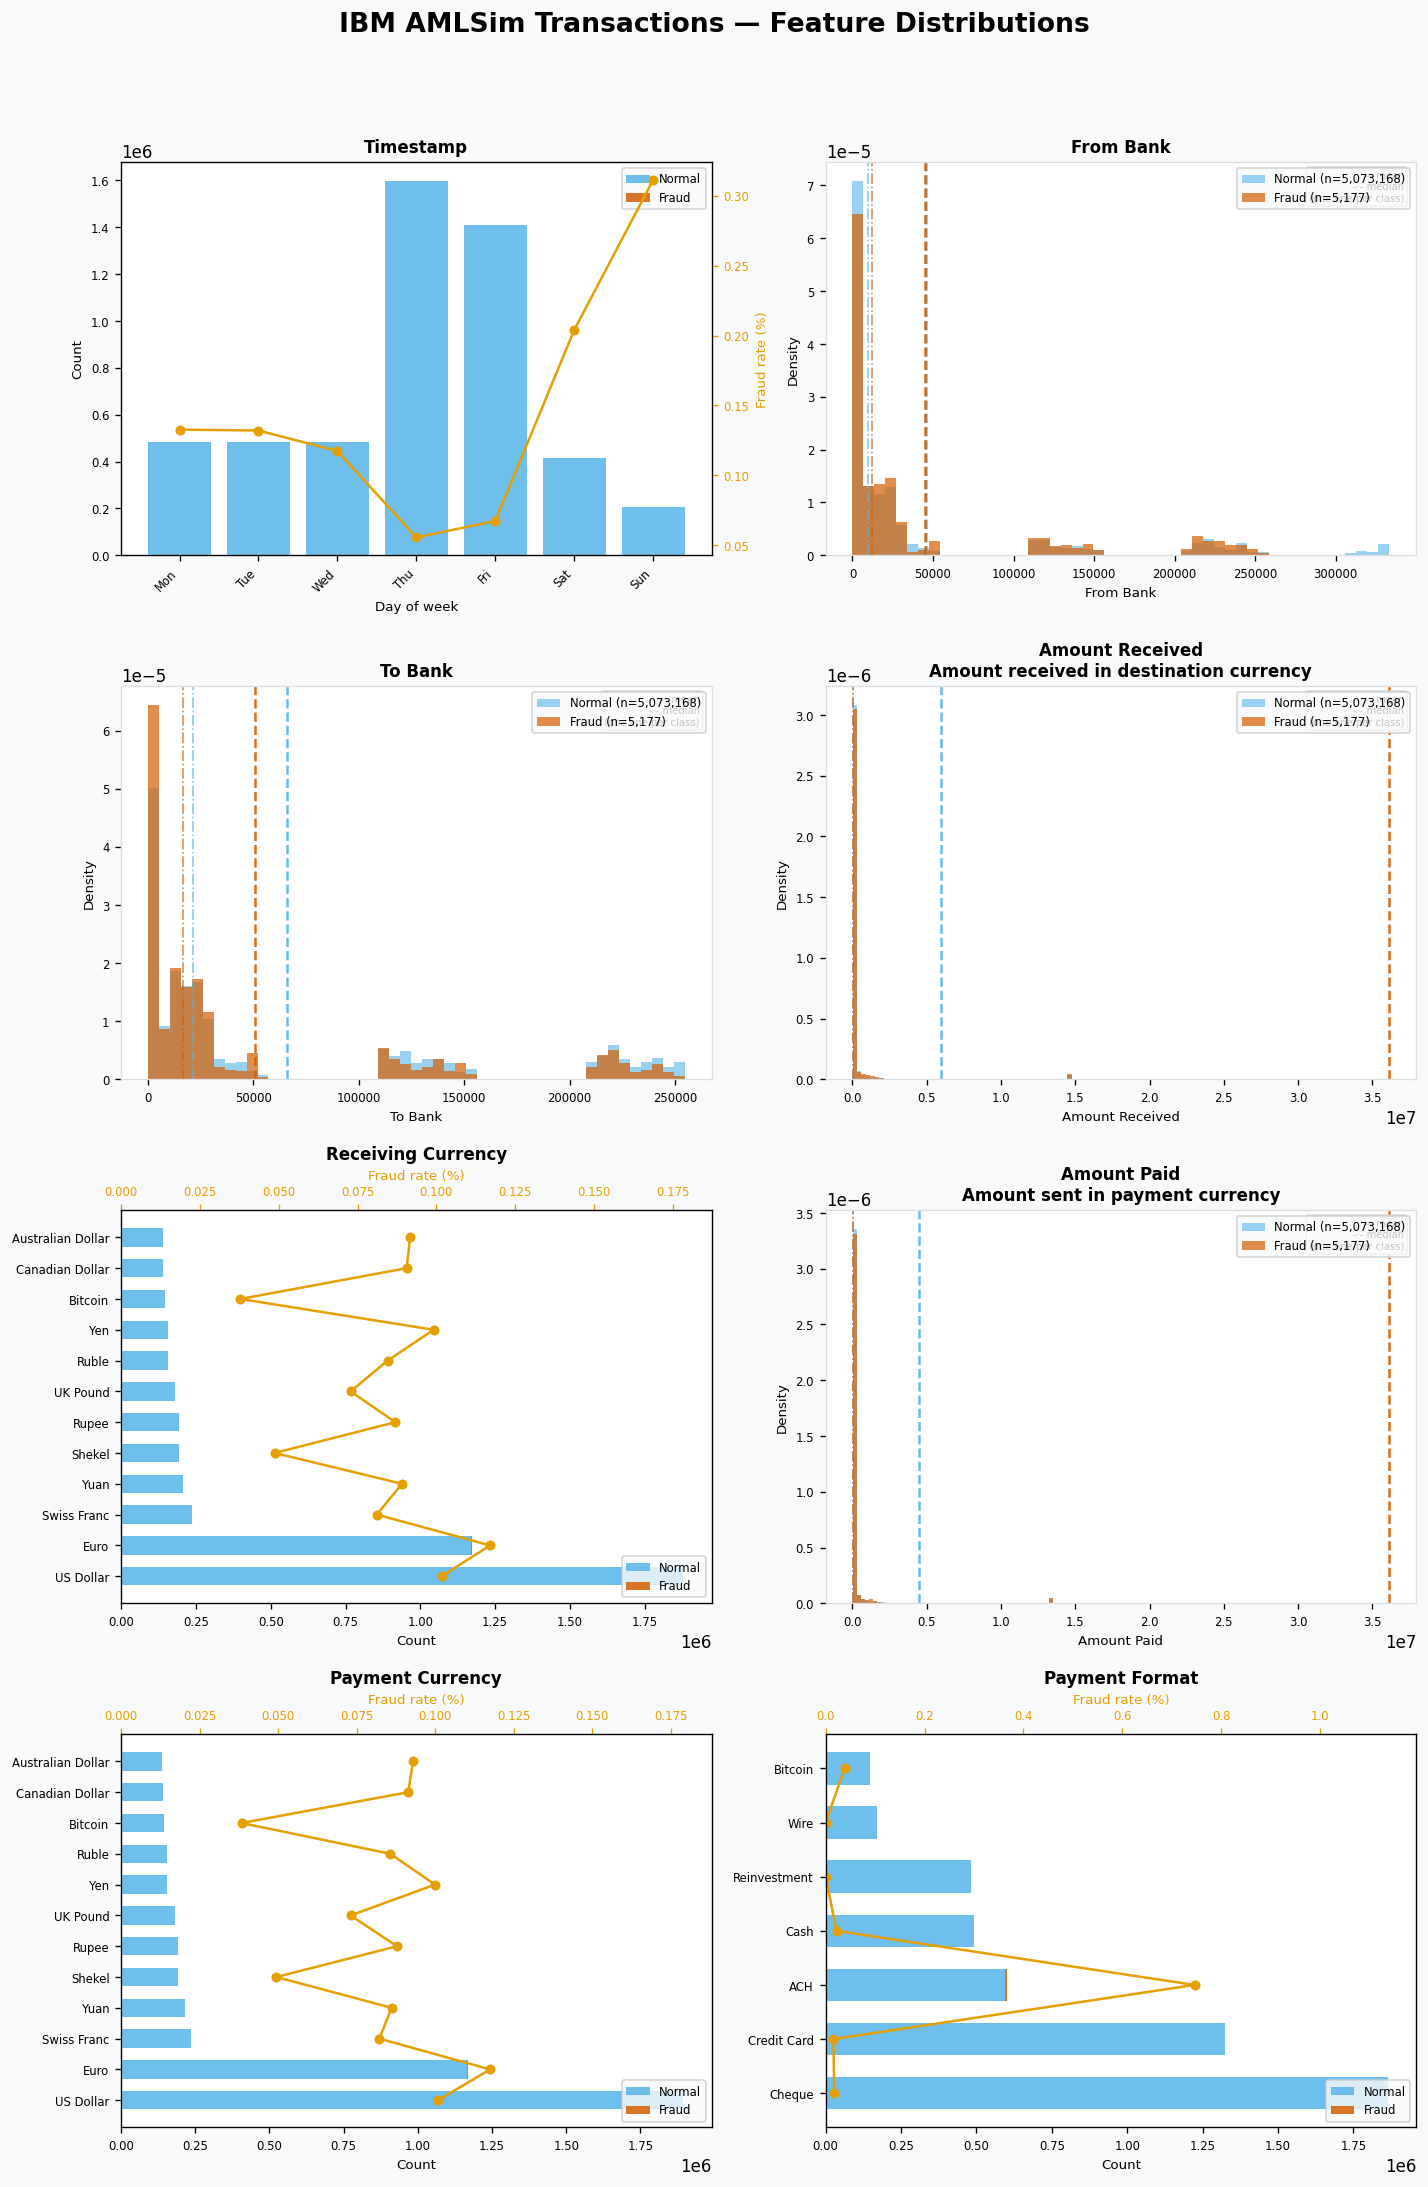

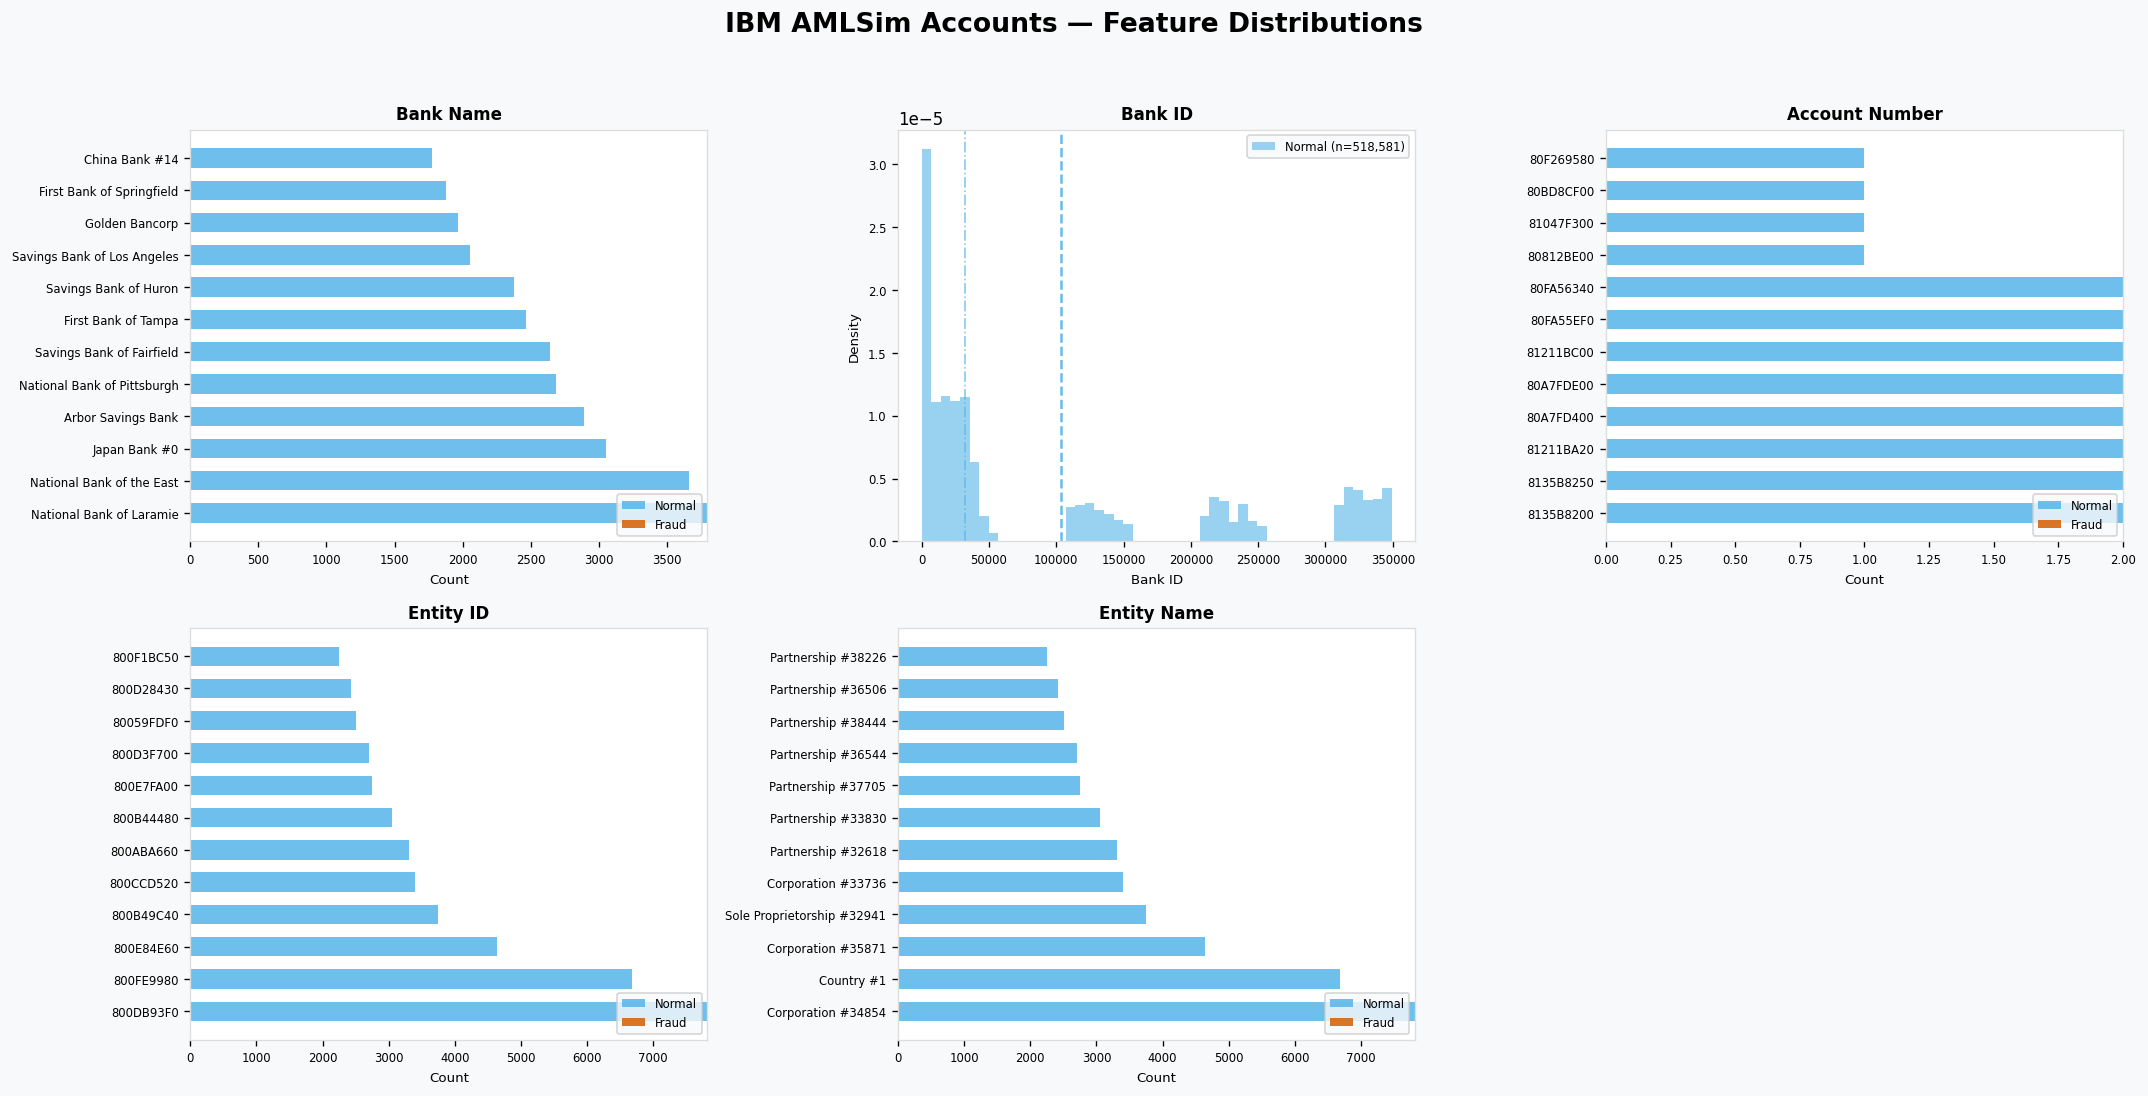

In [24]:
ibm_col_config = {
    "Is Laundering":   {"skip": True},
    "Account":         {"skip": True},
    "Account.1":       {"skip": True},
    "Timestamp":       {"time_format": "weekday"},
    "From Bank":       {"vlines_annotation": True},
    "To Bank":         {"vlines_annotation": True},
    "Amount Paid":     {"vlines_annotation": True,
                        "description": "Amount sent in payment currency"},
    "Amount Received": {"vlines_annotation": True,
                        "description": "Amount received in destination currency"},
}

if ibm_ok:
    ibm_loader.plot_distributions(title_prefix="IBM AMLSim Transactions", n_cols=2, col_config=ibm_col_config)
    
    acc_df = ibm_loader.get_accounts()
    if acc_df is not None:
        ibm_loader.plot_distributions(df=acc_df, title_prefix="IBM AMLSim Accounts")


### 1.4  Build the transaction graph

Uses `nx.from_pandas_edgelist` — much faster than row-by-row iteration.

In [25]:
if ibm_ok:
    ibm_graph = ibm_loader.build_graph()
    print(f"Nodes (accounts)    : {ibm_graph.number_of_nodes():,}")
    print(f"Edges (transactions): {ibm_graph.number_of_edges():,}")

Nodes (accounts)    : 515,080
Edges (transactions): 1,015,736


### 1.4 Cycles

In [26]:
import networkx as nx
import pandas as pd

if ibm_ok:
    # 1. Cycle rank (b_1) for the full graph
    # b_1 = |E| - |V| + WCC
    num_edges = ibm_graph.number_of_edges()
    num_nodes = ibm_graph.number_of_nodes()
    # For directed graphs, we use the weakly connected components
    wcc = nx.number_weakly_connected_components(ibm_graph)
    b1 = num_edges - num_nodes + wcc
    print(f"Cycle rank (b_1) of full graph: {b1:,}")

    # 2. Exact simple directed cycles for the fraud-only sub-graph
    # Find fraud nodes by iterating over the graph edges
    fraud_nodes = set()
    for u, v, d in ibm_graph.edges(data=True):
        if d.get('is_laundering') == 1:
            fraud_nodes.add(u)
            fraud_nodes.add(v)
            
    fraud_subgraph = ibm_graph.subgraph(fraud_nodes)
    fraud_cycles = list(nx.simple_cycles(fraud_subgraph))
    print(f"Exact simple directed cycles in fraud sub-graph: {len(fraud_cycles):,}")

    # 3. Capped estimation of simple directed cycles in the condensed (deduplicated) graph
    print("Calculating simple cycles on condensed graph (cap=50,000)...")
    # The graph returned by build_graph() is already an nx.DiGraph, which inherently deduplicates multiple edges between the same nodes.
    cycle_generator = nx.simple_cycles(ibm_graph)
    cycle_count = 0
    cap = 50000
    for _ in cycle_generator:
        cycle_count += 1
        if cycle_count >= cap:
            break
            
    if cycle_count >= cap:
        print(f"Simple directed cycles in condensed graph: >= {cap:,}")
    else:
        print(f"Simple directed cycles in condensed graph: {cycle_count:,}")


Cycle rank (b_1) of full graph: 614,790
Exact simple directed cycles in fraud sub-graph: 15,635
Calculating simple cycles on condensed graph (cap=50,000)...
Simple directed cycles in condensed graph: >= 50,000


### 1.5  Subgraph examples

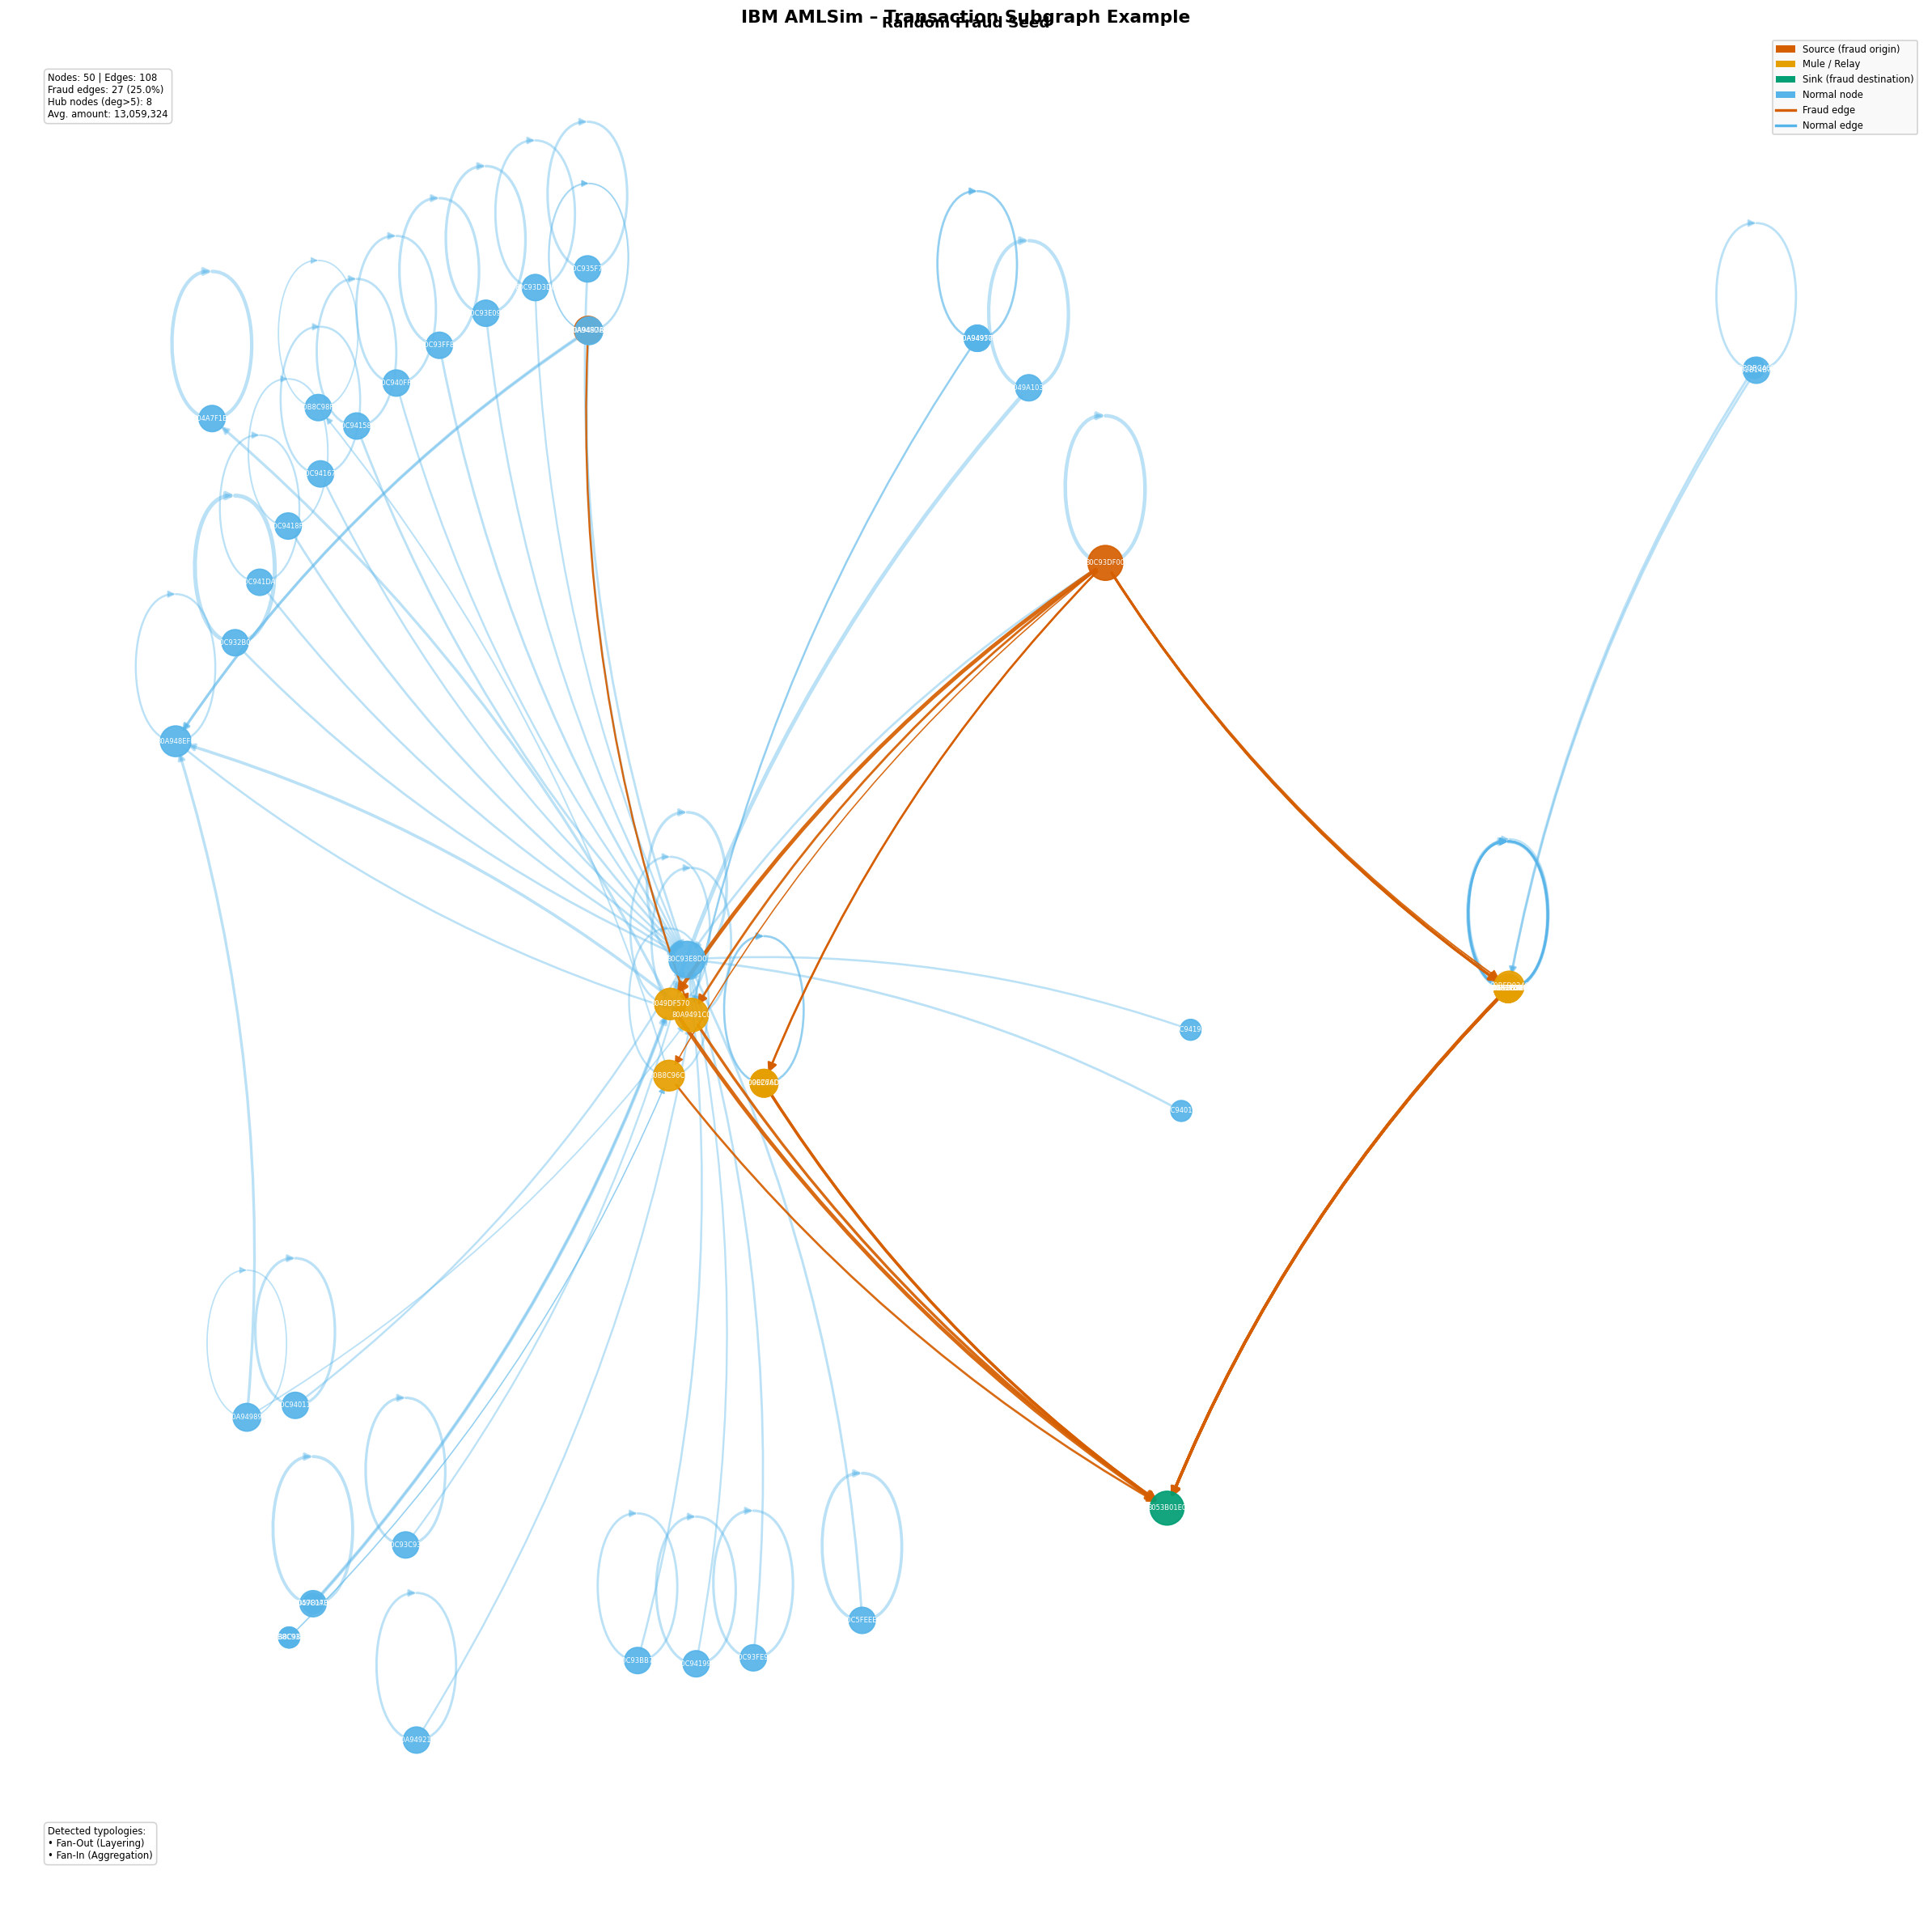

In [27]:
if ibm_ok:
    fig, ax = plt.subplots(1, 1, figsize=(20, 20))
    fig.suptitle("IBM AMLSim – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    ibm_loader.plot_subgraph(seed_node=20, max_nodes=50, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

This dataset seem to have a topology complex enough to be relevant for the detection of ML. 

---
## 2  AMLNet (AMLGentex-equivalent)

> **Source**: [Zenodo – AMLNet v2.0](https://zenodo.org/records/21237971)  (CC BY-NC 4.0, no account needed)  
> **Paper**: *AMLNet: A Knowledge-Guided Synthetic Benchmark for Machine Learning Evaluation in Anti-Money Laundering*  

### 2.1  Load

In [28]:
try:
    amlg_loader = DatasetFactory.get_loader("amlgentex")
    amlg_loader.load()
    amlg_loader.summary()
    amlg_df = amlg_loader.get_transactions()
    amlg_ok = True
except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    amlg_ok = False

Loading AMLNet (AMLGentex-equivalent) from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\global_classes\..\data\amlgentex\transactions.csv
  Loaded 1,090,000 rows.
  Dataset : AMLGentexLoader
  Rows    : 1,090,000
  Columns : 15
  Fraud   : 1,411  (0.1294 %)



In [29]:
if amlg_ok:
    print(amlg_df.head(5))

   step   type      amount    category nameOrig nameDest  oldbalanceOrg  \
0     0   BPAY  121.231873        Food    C4638    C1811  332687.934283   
1     0   OSKO   98.099062       Other    C5536    C6852  455880.908413   
2     0  DEBIT   93.861773  Healthcare     C450    C4987  266729.197862   
3     0   BPAY  156.833185       Other     C503      C99  497635.915154   
4     0  DEBIT   63.286125   Transport    C4791    C7610  350189.092731   

   newbalanceOrig  isFraud  isMoneyLaundering laundering_typology  hour  \
0   332566.702410        0                  0              normal    17   
1   455782.809350        0                  0              normal    18   
2   266635.336089        0                  0              normal    18   
3   497479.081970        0                  0              normal    18   
4   350125.806606        0                  0              normal    19   

   day_of_week  day_of_month  month  
0            0            13     10  
1            0        

### 2.2  Features

In [30]:
if amlg_ok:
    amlg_loader.print_features()


Column                Type         Description
--------------------------------------------------------------------------------
step                  int64        Sequential simulation step (transaction index)
type                  object       Transaction instrument / type  (e.g. ['BPAY', 'OSKO', 'DEBIT', 'TRANSFER', 'EFTPOS', 'CASH_OUT', 'NPP', 'PAYMENT'])
amount                float64      Transaction amount in Australian dollars (AUD)
category              object       Spending/transaction category  (e.g. ['Food', 'Other', 'Healthcare', 'Transport', 'Education', 'Housing', 'Recreation', 'Utilities'])
nameOrig              object       Originating account or customer identifier (node)
nameDest              object       Destination account, customer, or merchant identifier (node)
oldbalanceOrg         float64      Originating account balance before the transaction
newbalanceOrig        float64      Originating account balance after the transaction
isFraud               int64        

In [31]:
if amlg_ok:
    features_amlg = amlg_loader.get_features()
    pd.DataFrame([
        {
            "Column": col,
            "Type": meta["dtype"],
            "Description": meta["description"],
            "Possible Values": str(meta["possible_values"]) if meta["possible_values"] else "continuous",
        }
        for col, meta in features_amlg.items()
    ]).set_index("Column")

### 2.3  Distributions

c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\global_classes\dataset_loader.py:481: RuntimeWarning: invalid value encountered in divide
  rates = np.where(totals > 0, counts_f.values / totals * 100, 0.0)


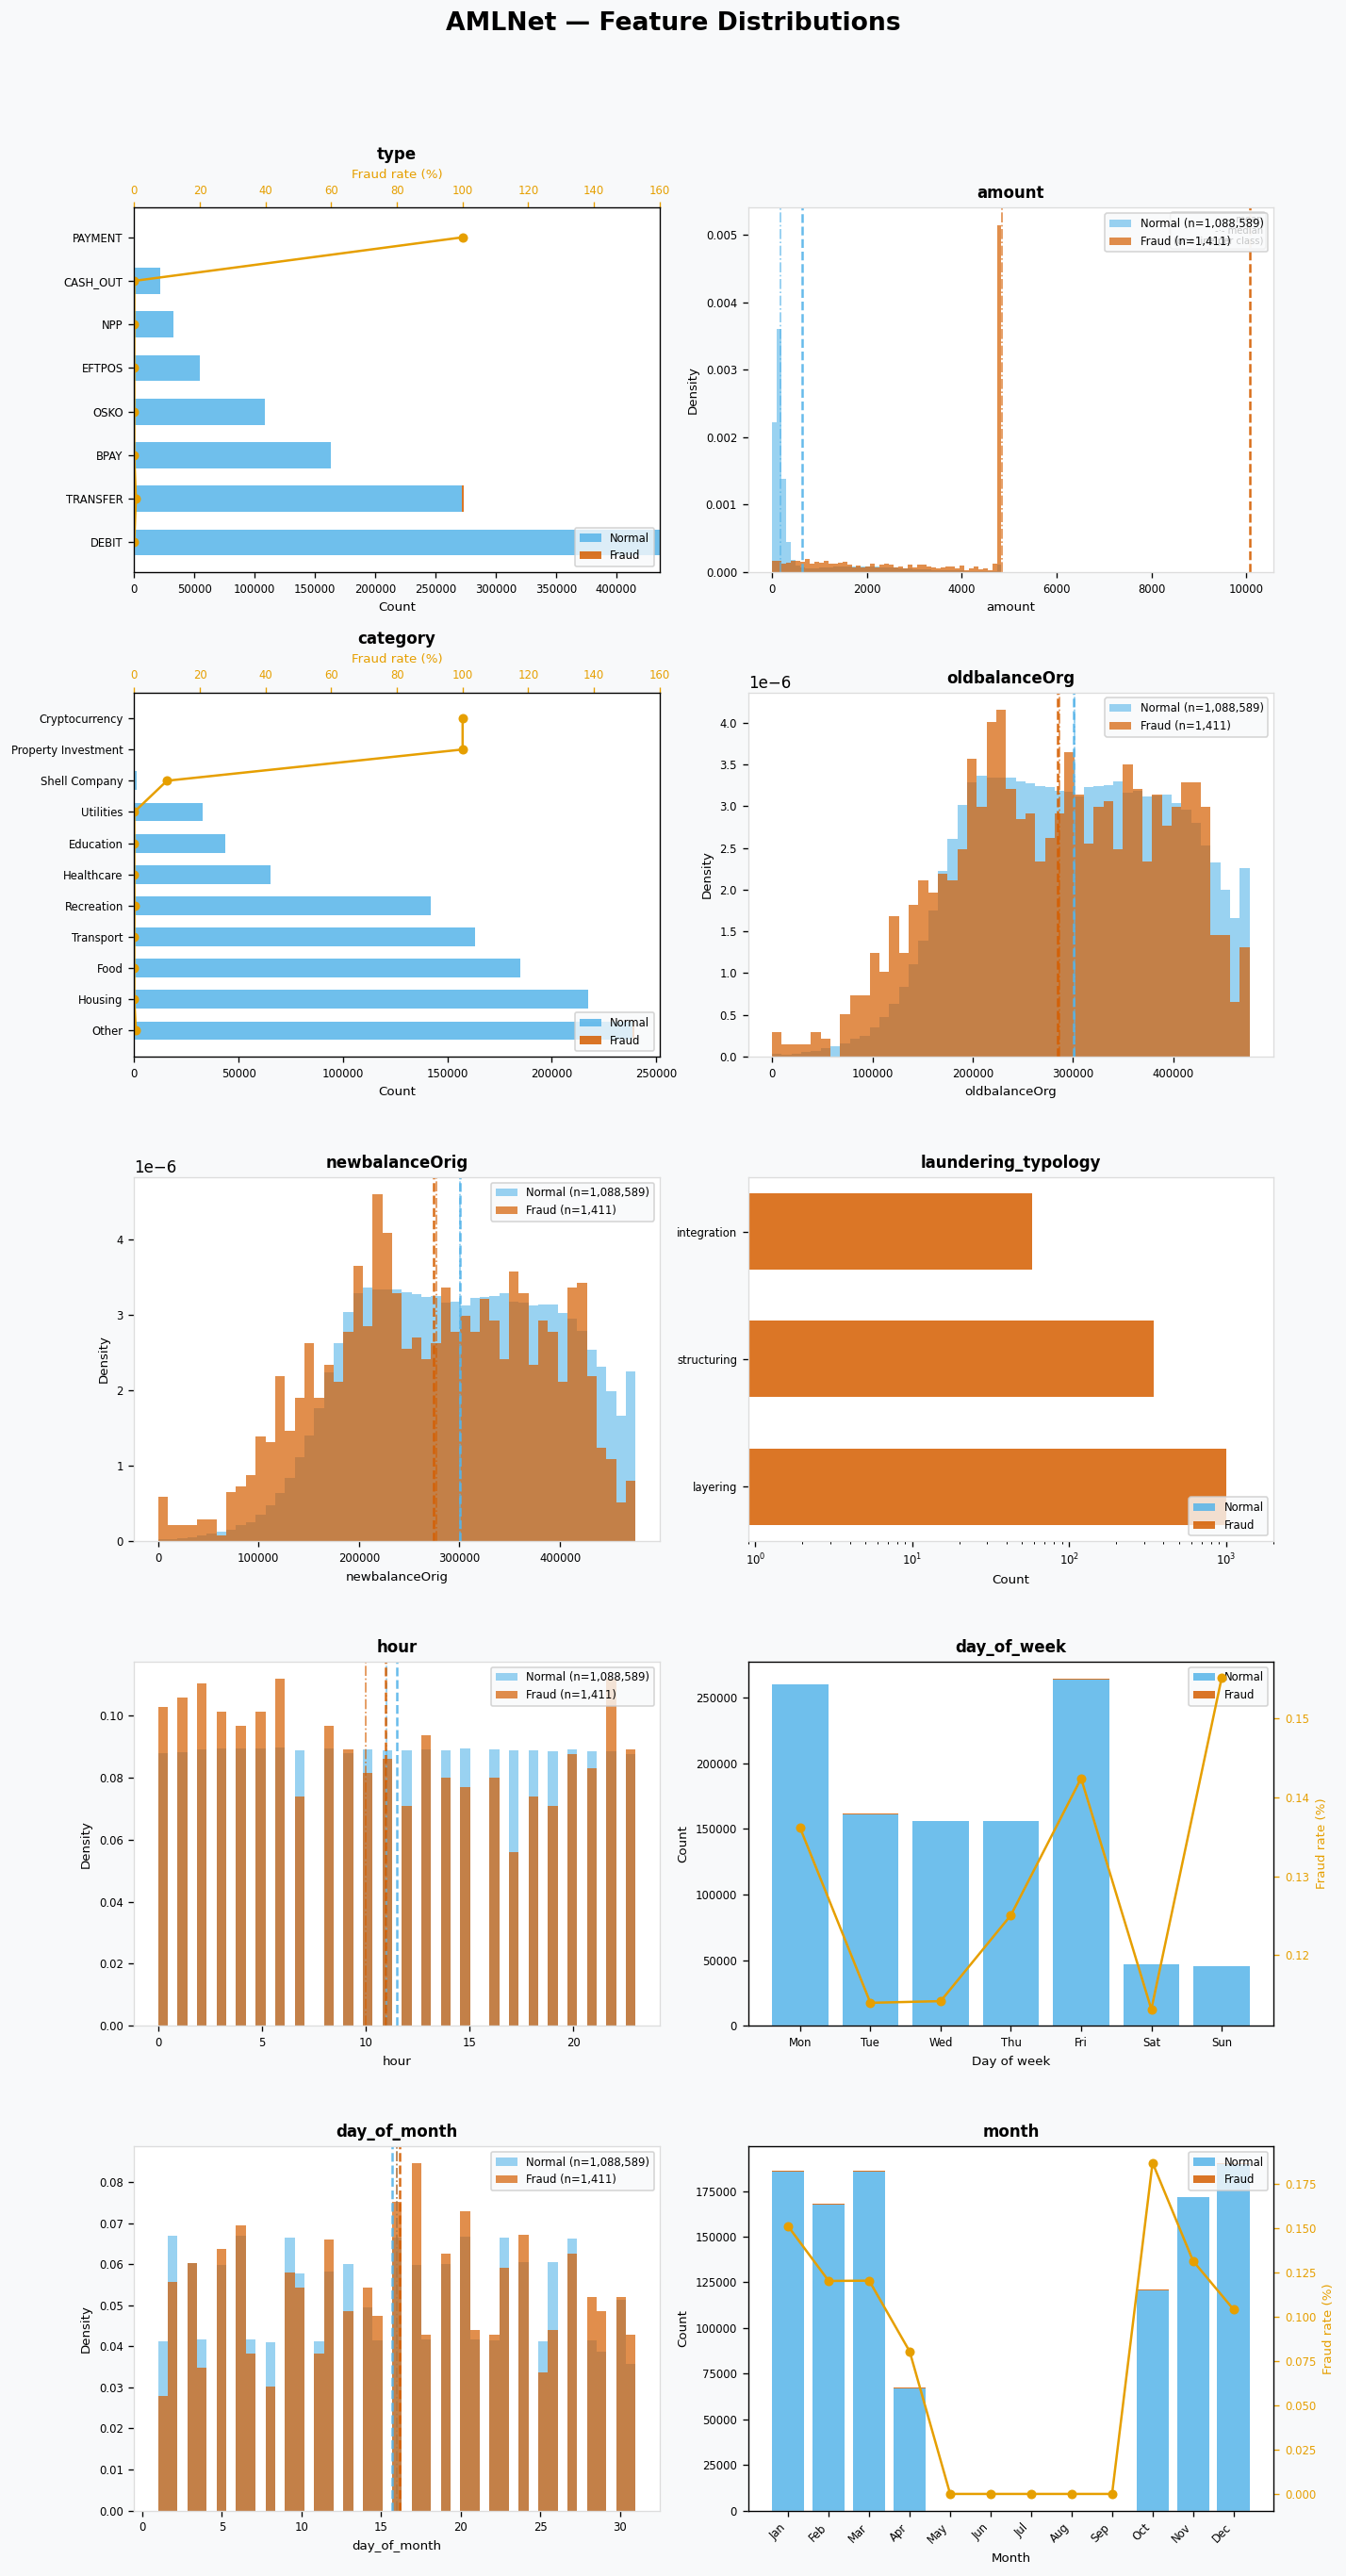

In [32]:
amlnet_col_config = {
    "step":               {"skip": True},
    "nameOrig":           {"skip": True},
    "nameDest":           {"skip": True},
    "isFraud":            {"skip": True},
    "isMoneyLaundering":  {"skip": True},
    "amount":             {"vlines_annotation": True},
    "laundering_typology":{"exclude_categories": ["normal"], "fraud_rate": False, "log_counts": True},
    "day_of_week":        {"time_format": "weekday_num"},
    "month":              {"time_format": "month_num"},
}

if amlg_ok:
    amlg_loader.plot_distributions(title_prefix="AMLNet", n_cols=2, col_config=amlnet_col_config)


### 2.4  Build the transaction graph

Uses `nx.from_pandas_edgelist` — much faster than row-by-row iteration.

In [33]:
if amlg_ok:
    amlg_graph = amlg_loader.build_graph()
    print(f"Nodes (accounts)    : {amlg_graph.number_of_nodes():,}")
    print(f"Edges (transactions): {amlg_graph.number_of_edges():,}")

Nodes (accounts)    : 11,000
Edges (transactions): 364,773


### 2.5  Subgraph examples

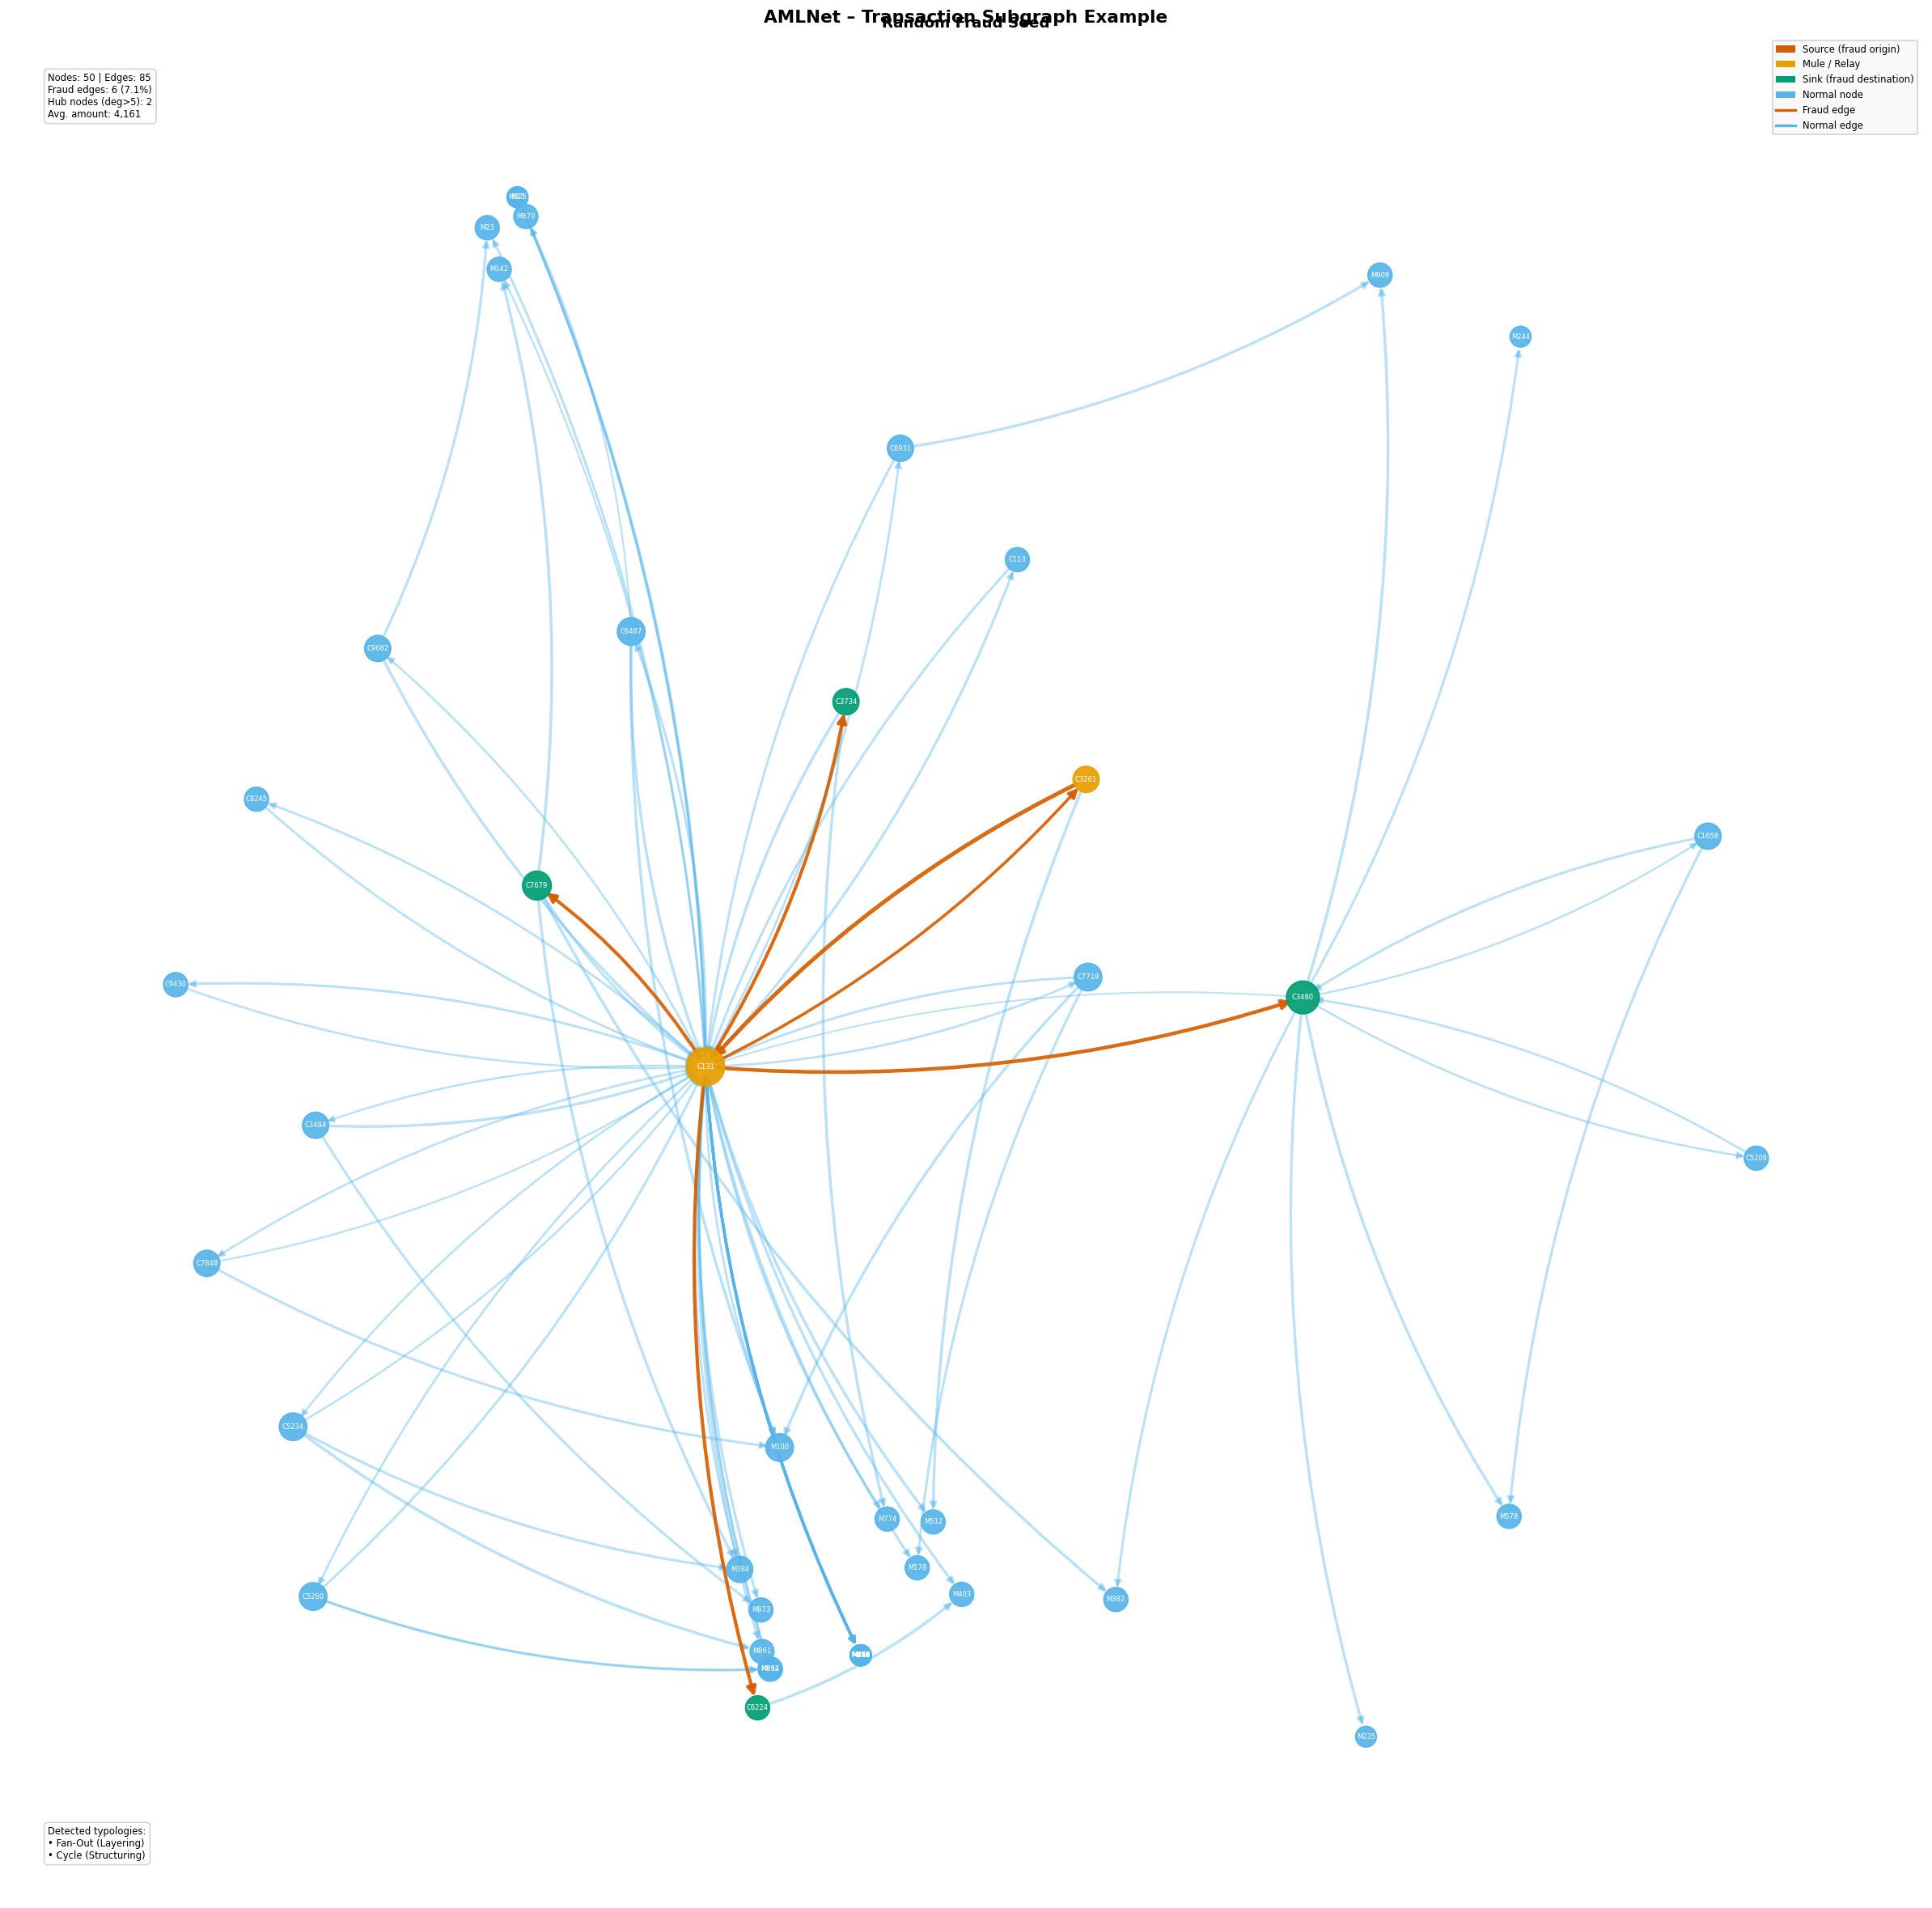

In [34]:
if amlg_ok:
    # plot_subgraph uses fast DataFrame BFS – no full graph needed.
    fig, ax = plt.subplots(1, 1, figsize=(20, 20))
    fig.suptitle("AMLNet – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    # We pass seed_node=None to let it randomly pick a fraudulent node, 
    # and max_nodes to bound the subgraph size.
    amlg_loader.plot_subgraph(seed_node=20, max_nodes=50, ax=ax, title="Random Fraud Seed", type_of_illicit="ML")
    
    plt.tight_layout()
    plt.show()

    # ML and Fraud column are exactly the same

By observing different subgraph i don't think that capturing topological features would be too usefull with these types of data. It seems to be more about frauds than money laundering, the colum money laundering and the column fraud are compleatly identical

---
## 3  SAML-D

> **Source**: [Kaggle – Synthetic Transaction Monitoring Dataset (SAML-D)](https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml)  
> **Paper**: Bournemouth University  



### 3.1  Load

In [35]:
try:
    saml_loader = DatasetFactory.get_loader("saml_d", nrows=500_000)
    saml_loader.load()
    saml_loader.summary()
    saml_df = saml_loader.get_transactions()
    saml_ok = True
except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    saml_ok = False

Loading SAML-D from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\global_classes\..\data\saml_d\SAML-D.csv
  (reading first 500,000 rows only)
  Loaded 500,000 rows.
  Dataset : SAMLDLoader
  Rows    : 500,000
  Columns : 12
  Fraud   : 556  (0.1112 %)



In [36]:
if saml_ok:
    saml_df.head(5)

### 3.2  Features

In [37]:
if saml_ok:
    saml_loader.print_features()


Column                   Type         Description
--------------------------------------------------------------------------------
Time                     object       Time of the transaction (HH:MM:SS)
Date                     object       Date of the transaction
Sender_account           int64        Sender account identifier (node)
Receiver_account         int64        Receiver account identifier (node)
Amount                   float64      Transaction amount
Payment_type             object       Payment instrument or method used  (e.g. ['Cash Deposit', 'Cross-border', 'Cheque', 'ACH', 'Credit card', 'Debit card'])
Sender_bank_location     object       Country or region of the sender's bank  (e.g. ['UK', 'Albania', 'Nigeria', 'Japan', 'Spain', 'Switzerland'])
Receiver_bank_location   object       Country or region of the receiver's bank  (e.g. ['UK', 'UAE', 'Spain', 'France', 'USA', 'Mexico'])
Payment_currency         object       Currency used by the sender  (e.g. ['UK pounds', 'I

In [38]:
if saml_ok:
    features_saml = saml_loader.get_features()
    pd.DataFrame([
        {
            "Column": col,
            "Type": meta["dtype"],
            "Description": meta["description"],
            "Possible Values": str(meta["possible_values"]) if meta["possible_values"] else "continuous",
        }
        for col, meta in features_saml.items()
    ]).set_index("Column")

### 3.3  Distributions

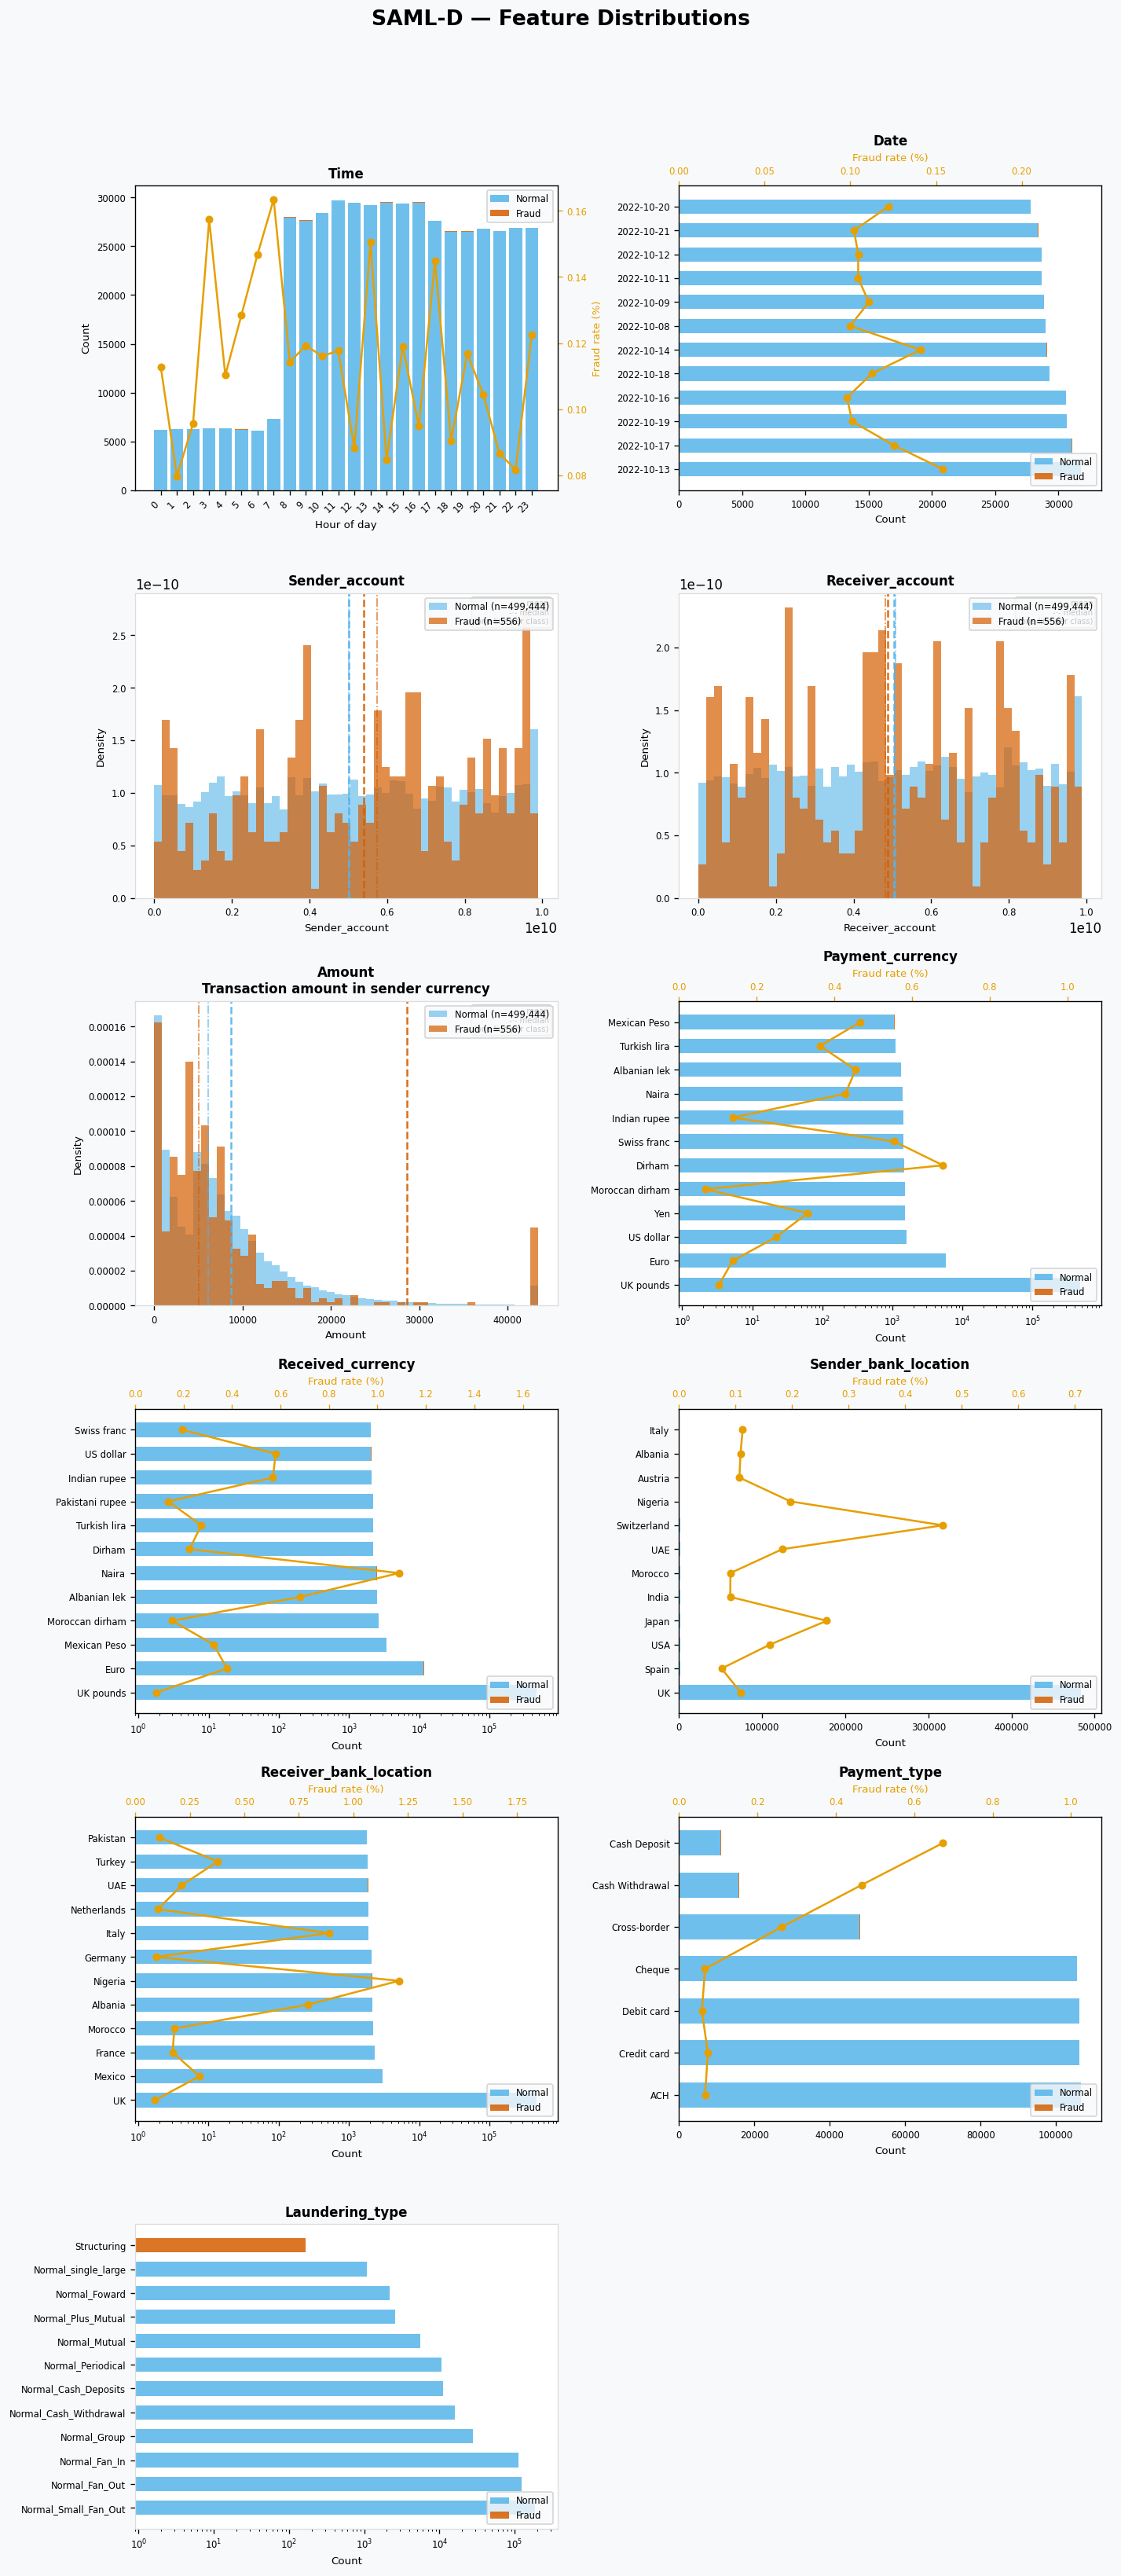

In [39]:
saml_col_config = {
    "Is_laundering":          {"skip": True},
    "Laundering_type":        {"fraud_rate": False, "log_counts": True},
    "Receiver_bank_location": {"log_counts": True},
    "Received_currency":      {"log_counts": True},
    "Payment_currency":       {"log_counts": True},
    "Amount":                 {"vlines_annotation": True,
                               "description": "Transaction amount in sender currency"},
    "Time":                   {"time_format": "hour"},
    "Sender_account":         {"vlines_annotation": True},
    "Receiver_account":       {"vlines_annotation": True},
}

if saml_ok:
    saml_loader.plot_distributions(title_prefix="SAML-D", n_cols=2, col_config=saml_col_config)


### 3.4  Build the transaction graph

Uses `nx.from_pandas_edgelist` — much faster than row-by-row iteration.

In [40]:
if saml_ok:
    saml_graph = saml_loader.build_graph()
    print(f"Nodes (accounts)    : {saml_graph.number_of_nodes():,}")
    print(f"Edges (transactions): {saml_graph.number_of_edges():,}")

Nodes (accounts)    : 206,772
Edges (transactions): 192,338


### 3.4 Cycles

In [41]:
import networkx as nx
import pandas as pd

if saml_ok:
    # 1. Cycle rank (b_1) for the full graph
    # b_1 = |E| - |V| + WCC
    num_edges = saml_graph.number_of_edges()
    num_nodes = saml_graph.number_of_nodes()
    # For directed graphs, we use the weakly connected components
    wcc = nx.number_weakly_connected_components(saml_graph)
    b1 = num_edges - num_nodes + wcc
    print(f"Cycle rank (b_1) of full graph: {b1:,}")

    # 2. Exact simple directed cycles for the fraud-only sub-graph
    # Find fraud nodes by iterating over the graph edges
    fraud_nodes = set()
    for u, v, d in saml_graph.edges(data=True):
        if d.get('is_laundering') == 1:
            fraud_nodes.add(u)
            fraud_nodes.add(v)
            
    fraud_subgraph = saml_graph.subgraph(fraud_nodes)
    fraud_cycles = list(nx.simple_cycles(fraud_subgraph))
    print(f"Exact simple directed cycles in fraud sub-graph: {len(fraud_cycles):,}")

    # 3. Capped estimation of simple directed cycles in the condensed (deduplicated) graph
    print("Calculating simple cycles on condensed graph (cap=50,000)...")
    # The graph returned by build_graph() is already an nx.DiGraph, which inherently deduplicates multiple edges between the same nodes.
    cycle_generator = nx.simple_cycles(saml_graph)
    cycle_count = 0
    cap = 50000
    for _ in cycle_generator:
        cycle_count += 1
        if cycle_count >= cap:
            break
            
    if cycle_count >= cap:
        print(f"Simple directed cycles in condensed graph: >= {cap:,}")
    else:
        print(f"Simple directed cycles in condensed graph: {cycle_count:,}")


Cycle rank (b_1) of full graph: 4,775
Exact simple directed cycles in fraud sub-graph: 0
Calculating simple cycles on condensed graph (cap=50,000)...
Simple directed cycles in condensed graph: 4,753


### 3.5  Subgraph examples

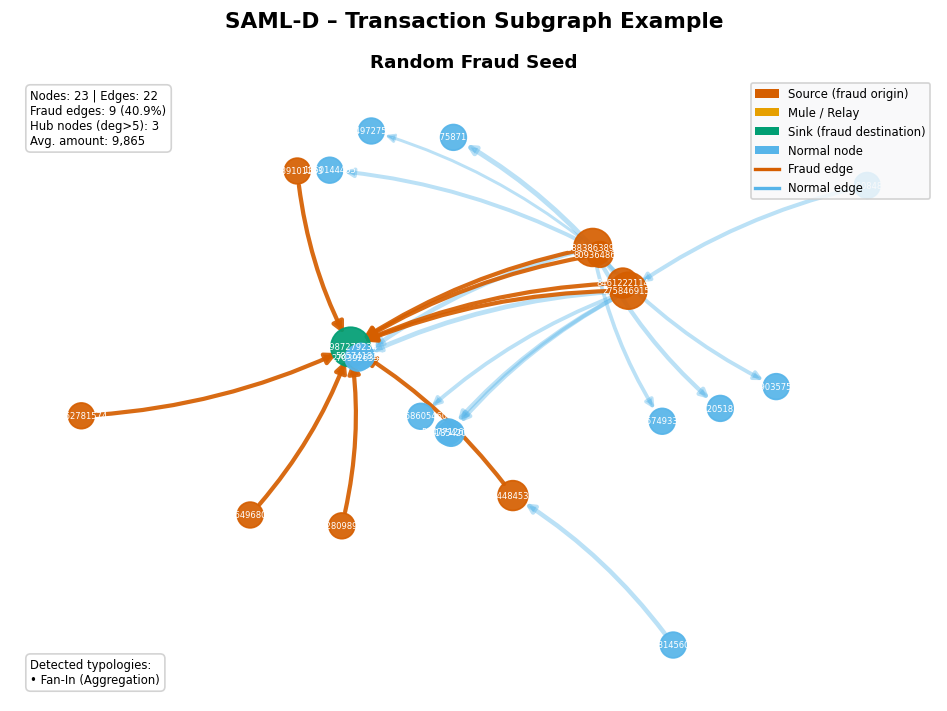

In [42]:
if saml_ok:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.suptitle("SAML-D – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    saml_loader.plot_subgraph(seed_node=3, max_nodes=300, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

This dataset provides really sparse graphs. Sometimes ML schemas presents intresting topologies that could be exploited by our algorithm

---
## 4  Cross-Dataset Comparison

In [43]:
def dataset_stats(loader, name, ok):
    if not ok:
        return {"Dataset": name, "Status": "⚠️ file not found",
                "Rows": "—", "Columns": "—", "Fraud count": "—",
                "Fraud %": "—", "Nodes": "—", "Edges": "—"}
    df = loader.get_transactions()
    fraud_col = loader._fraud_column()
    n = len(df)
    n_fraud = int(df[fraud_col].sum())
    g = loader._graph
    return {
        "Dataset": name,
        "Status": "✅ loaded",
        "Rows": f"{n:,}",
        "Columns": len(df.columns),
        "Fraud count": f"{n_fraud:,}",
        "Fraud %": f"{100 * n_fraud / n:.4f}%",
        "Nodes": f"{g.number_of_nodes():,}" if g else "—",
        "Edges": f"{g.number_of_edges():,}" if g else "—",
    }

comparison = pd.DataFrame([
    dataset_stats(ibm_loader if ibm_ok else None, "IBM AMLSim (HI-Small)", ibm_ok),
    dataset_stats(amlg_loader if amlg_ok else None, "AMLNet (AMLGentex-equiv.)", amlg_ok),
    dataset_stats(saml_loader if saml_ok else None, "SAML-D (first 500k rows)", saml_ok),
])
comparison.set_index("Dataset")

,Status,Rows,Columns,Fraud count,Fraud %,Nodes,Edges
Dataset,,,,,,,
IBM AMLSim (HI-Small),✅ loaded,"5,078,345",11,"5,177",0.1019%,"515,080","1,015,736"
AMLNet (AMLGentex-equiv.),✅ loaded,"1,090,000",15,"1,411",0.1294%,"11,000","364,773"
SAML-D (first 500k rows),✅ loaded,"500,000",12,556,0.1112%,"206,772","192,338"


# Conclusions

From this brief analysis I think that the dataset that best mimics real word fraud rings for money laundering is the IBM AMLSim, in future steps we will use the medium or large version to have more data spreaded through a longer timespan (from the graphs we can see that the current period goes from january to april).

SAML_D also sometimes shows intresting topological structures.

I will focus on IBM AMLSim providing a deeper analysis that mesures the betti numbers: $ b_0 $ is the number of connected components, $ b_1 $ the number of cycles.

It's safe to exclued AMLGentex due to the lack of intresting topological structures for the fraud schemes.